# Validation of the CorrectionDispersion_PIML Module

This section presents the standalone validation of the CorrectionDispersion_PIML model, with the goal of verifying the physical consistency of the corrected maps with respect to the original Gaussian dispersion generated by the GaussianPuff engine. The validation is performed on all maps in the dataset and includes both quantitative analyses and visual comparisons.

The main activities include:
- consistent normalization of the Gaussian map using the 95th percentile (p95);
- requesting the corrected map from the PIML microservice using the raw (non-normalized) map;
- computation of autonomous metrics: RMSE in free space, Smoothness Index, and Wind-Alignment Score;
- saving results in CSV format;
- comparative visualization of the maps (Original, PIML, Difference);
- statistical analysis via boxplots;
- stress testing of the model behavior as wind speed varies.

This validation is not intended to compare the model with previous versions, but to verify the physical consistency, numerical stability, and qualitative behavior of the PIML model under controlled urban conditions.

# 0) IMPORTS

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils_piml import (
    load_gaussian_map,
    load_building_map,
    request_piml_map
)

from metrics import (
    rmse_free,
    smoothness_index,
    wind_alignment_score,
    building_violation
)

# 1) INTERNAL CONFIG

In [ ]:
BINARY_MAP_PATH = "../../CorrectionDispersion_PIML/binary_maps_data/amsterdam_netherlands_bbox.npy"
NPY_DIR = "../../CorrectionDispersion_PIML/dataset/real_dispersion/"

ALL_FILES = sorted([
    f for f in os.listdir(NPY_DIR)
    if f.endswith(".npy") and f.startswith("sim_")
])
print("Total number of maps found:", len(ALL_FILES))

Numero totale mappe trovate: 300


# 2) LOADING BINARY MAP

In [3]:

binary_map = load_building_map(BINARY_MAP_PATH)
print("Binary map shape:", binary_map.shape)

Binary map shape: (500, 500)


# 3) VALIDATION ON THE WHOLE DATASET

In [ ]:
results = []

wind_speed = 3.5
wind_dir_list = [225.0] * 24

for fname in ALL_FILES:
    fullpath = os.path.join(NPY_DIR, fname)
    gaussian_map = load_gaussian_map(fullpath)
    p95 = np.percentile(gaussian_map, 95)
    gaussian_norm = gaussian_map / (p95 + 1e-6)
    gaussian_norm = np.clip(gaussian_norm, 0, 1)
    corrected_map, model_version = request_piml_map(
        gaussian_map,
        binary_map,
        wind_speed,
        wind_dir_list
    )

    m_rmse = rmse_free(corrected_map, gaussian_norm, binary_map)
    m_smooth = smoothness_index(corrected_map)
    m_wind = wind_alignment_score(corrected_map, np.mean(wind_dir_list))
    m_build = building_violation(corrected_map, binary_map)
    sim_id = int(fname.split("_")[1])
    results.append({
        "sim": sim_id,
        "rmse_free": m_rmse,
        "smoothness": m_smooth,
        "wind_alignment": m_wind,
        "building_violation": m_build
    })

print("VALIDATION COMPLETED.")

VALIDAZIONE COMPLETATA.


# 4) CSV SAVING

In [ ]:
df = pd.DataFrame(results)
df = df.sort_values("sim")
df.to_csv("validation_results_piml.csv", index=False)
df.head(), df.tail()

(     sim  rmse_free  smoothness  wind_alignment  building_violation
 0      0   0.023558    0.010714        0.069849            0.001136
 111    1   0.029625    0.011983        0.068341            0.002384
 222    2   0.024243    0.010650        0.069982            0.000472
 233    3   0.023271    0.010714        0.069743            0.000516
 244    4   0.023484    0.010511        0.070207            0.000472,
      sim  rmse_free  smoothness  wind_alignment  building_violation
 216  295   0.023163    0.010667        0.069739            0.000484
 217  296   0.023011    0.010572        0.070099            0.000584
 218  297   0.023587    0.010716        0.069906            0.000744
 219  298   0.023590    0.010764        0.069857            0.000472
 220  299   0.025058    0.011481        0.068803            0.000684)

# 5) Map comparison view

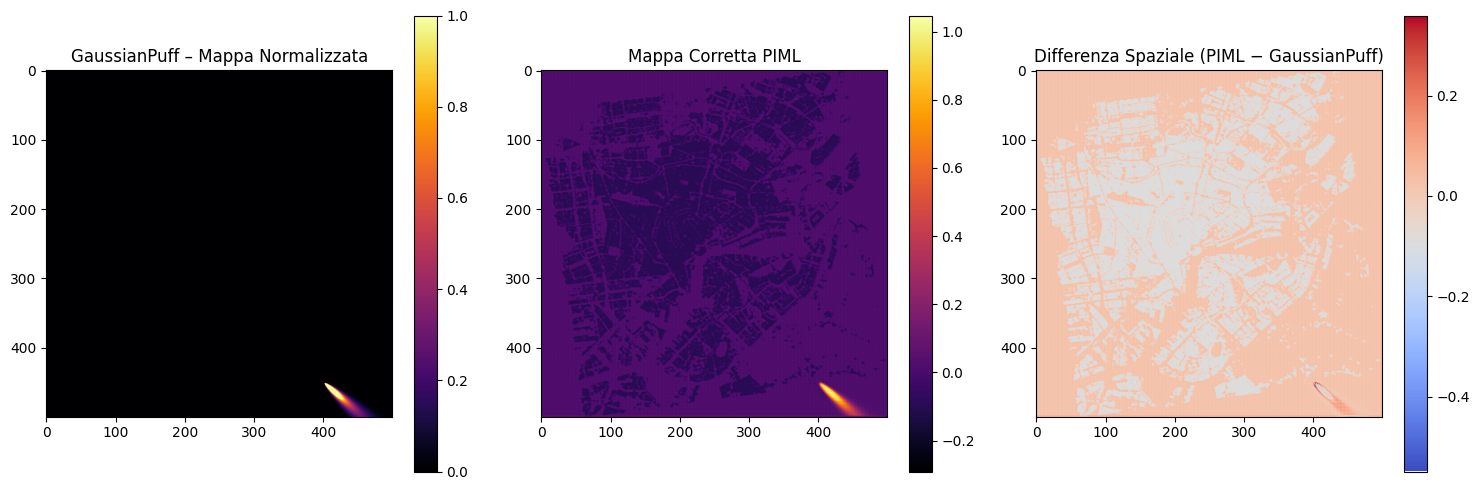

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title("Gaussian Puff – Normalized Map", fontsize=12)
plt.imshow(gaussian_norm, cmap="inferno")
plt.colorbar()
plt.subplot(1,3,2)
plt.title("Corrected PIML Map", fontsize=12)
plt.imshow(corrected_map, cmap="inferno")
plt.colorbar()
plt.subplot(1,3,3)
plt.title("Spatial Difference (PIML − Gaussian Puff)", fontsize=12)
plt.imshow(corrected_map - gaussian_norm, cmap="coolwarm")
plt.colorbar()
plt.tight_layout()
plt.show()

# 6) Boxplot metrics on all maps

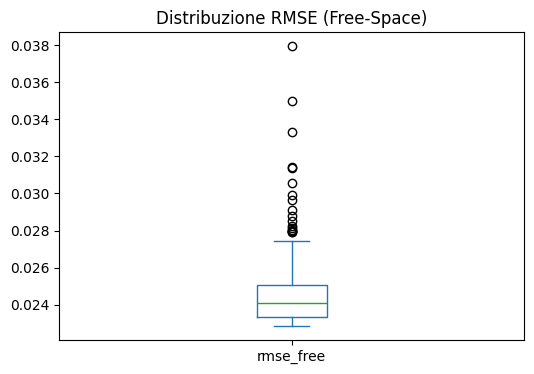

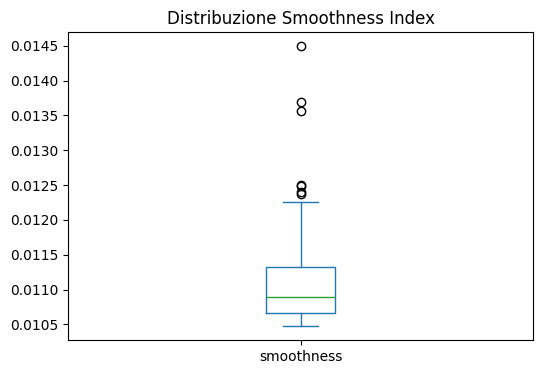

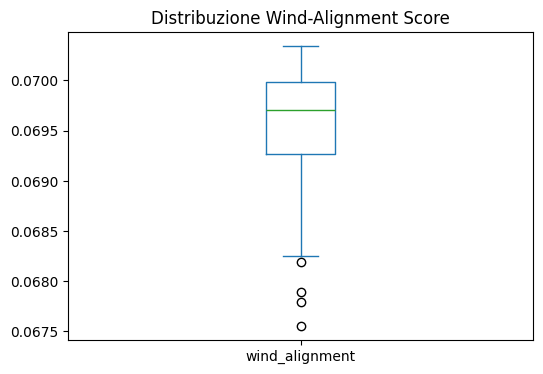

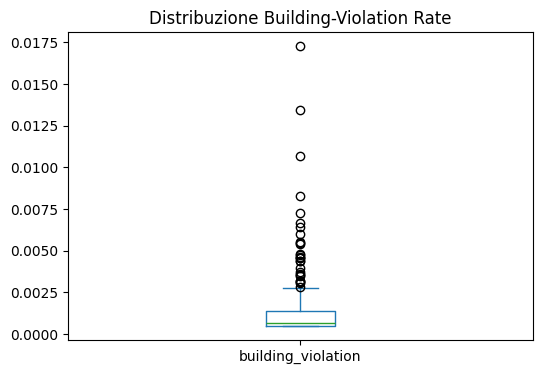

In [7]:
for col in ["rmse_free", "smoothness", "wind_alignment", "building_violation"]:
    plt.figure(figsize=(6,4))
    df[col].plot(kind="box")
    titles = {
        "rmse_free": "Distribuzione RMSE (Free-Space)",
        "smoothness": "Distribuzione Smoothness Index",
        "wind_alignment": "Distribuzione Wind-Alignment Score",
        "building_violation": "Distribuzione Building-Violation Rate"
    }
    plt.title(titles[col], fontsize=12)
    plt.show()

# 7) Wind stress test

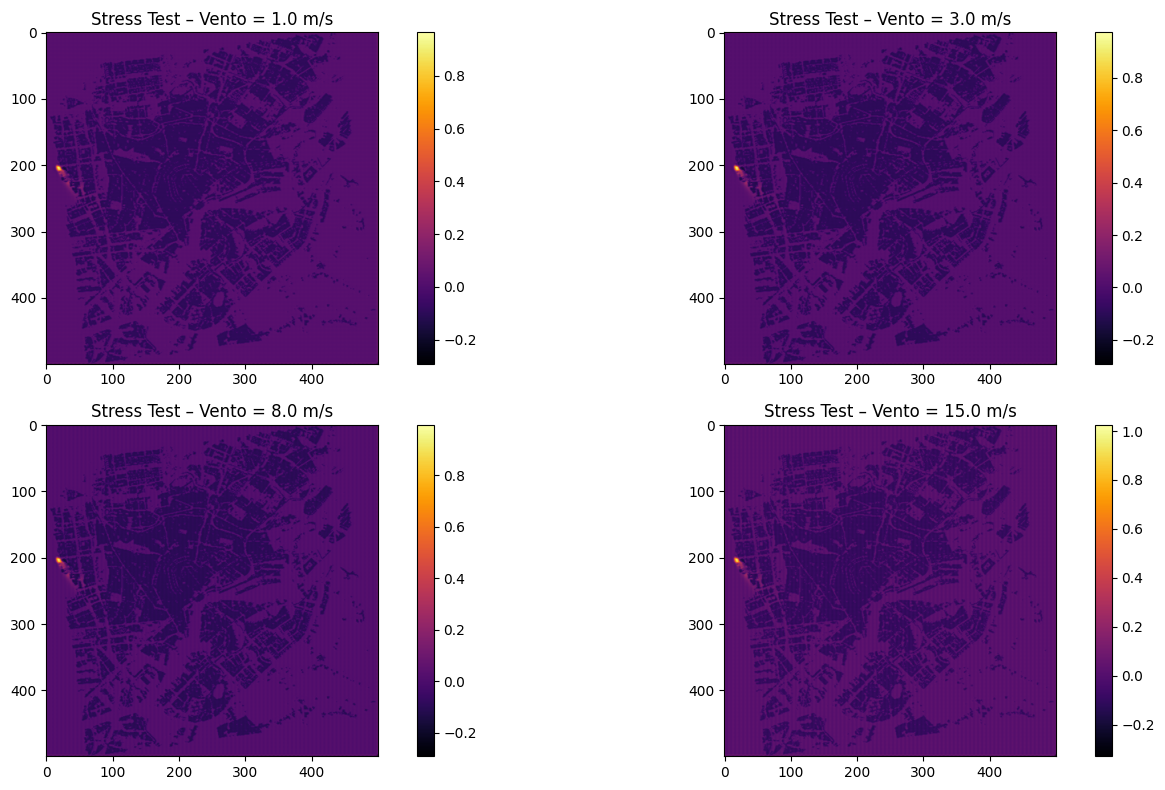

In [ ]:
binary_map = load_building_map(BINARY_MAP_PATH)
path = os.path.join(NPY_DIR, "sim_0_conc_real_2025-11-24.npy")
gauss = load_gaussian_map(path)
p95_stress = np.percentile(gauss, 95)
gauss_norm = gauss / (p95_stress + 1e-6)
gauss_norm = np.clip(gauss_norm, 0, 1)
wind_tests = [1.0, 3.0, 8.0, 15.0]
results_stress = {}

for ws in wind_tests:
    corrected, _ = request_piml_map(
        gauss,
        binary_map,
        ws,
        [225.0] * 24
    )
    results_stress[ws] = corrected

plt.figure(figsize=(15, 8))
for i, ws in enumerate(wind_tests):
    plt.subplot(2, 2, i+1)
    plt.title(f"Stress Test – Wind = {ws} m/s", fontsize=12)
    plt.imshow(results_stress[ws], cmap="inferno")
    plt.colorbar()

plt.tight_layout()
plt.show()

# PIML Validation Conclusions

The obtained results show that the CorrectionDispersion_PIML module produces dispersion maps that are consistent with the physics of the phenomenon and with urban geometry. The metric analysis highlights contained RMSE values in free-space areas, a stable Smoothness Index, and a Wind-Alignment Score that confirms the correct gradient directionality with respect to the dominant wind.

Qualitative visualizations show that the model correctly attenuates concentrations in built-up areas and reinforces the plume in regions consistent with wind direction and urban morphology. The stress test across different wind speeds highlights robust and stable behavior of the encoder–decoder architecture.

Overall, the model proves to be physically consistent and suitable for operational integration within the MLOps pipeline microservices. The consolidated results form the basis for subsequent analyses (Phase 5.2–5.5).